# Эксперимент BlocksNetAgent

Блокнот для прогона одного эксперимента над агентом городской аналитики.

**Вход** (ячейка параметров ниже): модель, число итераций, вопрос.

**Выход:**
- структурированный ответ (секции `ANALYSIS PLAN / RESULT / REFLECTION / HYPOTHESES / ...`), `confidence`, `limitations`;
- логи: сообщения LangChain (с токенами) + `run_log.md/json` каталога запуска;
- использованные инструменты (таблица вызовов с частотой);
- схемы — картограммы метрик (`maps/*.png`) и список сохранённых CSV.

> Требуется заполненный `.env` (`FP2MP_CHAT_URL`, `FP2MP_API_KEY`) и данные модели в `data/` (`blocks_with_services.gpkg`, `acc_mx.pickle`). Запускать из корня проекта или из `examples/`.

In [1]:
# --- ПАРАМЕТРЫ ЭКСПЕРИМЕНТА (вход) ---
MODEL = "openai/gpt-4o"        # имя модели у OpenAI-совместимого бэкенда
MAX_ITERATIONS = 10                  # лимит шагов ReAct-цикла AgentExecutor
QUESTION = (
    "что нужно разместить в квартале 603?"
)

In [2]:
# --- ОКРУЖЕНИЕ ---
import json
import sys
import time
from pathlib import Path

from dotenv import load_dotenv

# Находим корень проекта (каталог с пакетом blocksnet_agent)
ROOT = Path.cwd()
if not (ROOT / "blocksnet_agent").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
load_dotenv(ROOT / ".env")

from blocksnet_agent import BlocksNetAgent

print("Проект:   ", ROOT)
print("Модель:   ", MODEL)
print("Итераций: ", MAX_ITERATIONS)
print("Вопрос:   ", QUESTION)

Проект:    p:\AI_asistent\ITMO\blocksnet-agent
Модель:    openai/gpt-4o
Итераций:  10
Вопрос:    что нужно разместить в квартале 603?


In [3]:
# --- ЗАПУСК ---
agent = BlocksNetAgent(model=MODEL, max_iterations=MAX_ITERATIONS)

t0 = time.time()
result = agent.run(QUESTION)
elapsed = time.time() - t0

run_dir = Path(result.get("run_dir") or "")
print(f"Готово за {elapsed:.1f} c | confidence = {result.get('confidence')}")
print("Каталог запуска:", run_dir)

2026-06-16 22:15:10.374 | INFO     | blocksnet.analysis.provision.competitive.core:_initialize_provision_df:29 - Initializing provision DataFrame
2026-06-16 22:15:10.376 | WARNING  | blocksnet.analysis.provision.competitive.core:_initialize_provision_df:33 - No demand in columns. Imputing using population column and demand parameter
2026-06-16 22:15:10.388 | INFO     | blocksnet.analysis.provision.competitive.core:_supply_self:56 - Supplying blocks with own capacities
2026-06-16 22:15:10.402 | INFO     | blocksnet.analysis.provision.competitive.core:competitive_provision:190 - Setting and solving LP problems until max depth or break condition reached
2026-06-16 22:15:11.014 | SUCCESS  | blocksnet.analysis.provision.competitive.core:competitive_provision:203 - Provision assessment finished
2026-06-16 22:15:11.020 | INFO     | blocksnet.analysis.provision.competitive.core:_initialize_provision_df:29 - Initializing provision DataFrame
2026-06-16 22:15:11.021 | WARNING  | blocksnet.analysi

Готово за 125.7 c | confidence = 0.62
Каталог запуска: p:\AI_asistent\ITMO\blocksnet-agent\outputs\run_20260616-221500-ad2c19


## 1. Ответ

In [4]:
print(result["output"])

ANALYSIS PLAN: Вопрос: что нужно разместить в квартале 603?
Для ответа на этот вопрос необходимо оценить текущую обеспеченность квартала 603 сервисами, его доступность и связность, а также разнообразие и плотность сервисов. Это позволит выявить дефициты и предложить улучшения.

1. **Обеспеченность сервисами**: 
   - Гипотеза: Квартал 603 имеет недостаточную обеспеченность базовыми сервисами по сравнению с другими кварталами.
   - Инструмент: compute_service_provision для базовых сервисов, чтобы оценить обеспеченность по каждому типу сервиса.

2. **Доступность и связность**:
   - Гипотеза: Улучшение доступности в квартале 603 повысит его обеспеченность сервисами.
   - Инструмент: propose_zone_development для генерации сценария улучшения, затем compute_scenario_provision для оценки before→after изменений в обеспеченности.

3. **Связность**:
   - Гипотеза: Квартал 603 имеет более низкую связность по сравнению с медианой других кварталов.
   - Инструмент: compute_connectivity для оценки св

In [5]:
# Самооценка и разбор по секциям
print("CONFIDENCE:", result.get("confidence"))

print("\nLIMITATIONS:")
for lim in (result.get("limitations") or ["\u2014"]):
    print("  -", lim)

print("\n\u0421\u0415\u041a\u0426\u0418\u0418:")
for name, body in (result.get("sections") or {}).items():
    print(f"\n=== {name} ===")
    print(body)

CONFIDENCE: 0.62

LIMITATIONS:
  - - Анализ ограничен данными локальной модели и не учитывает внешние факторы, такие как изменения в транспортной инфраструктуре или демографические изменения.
  - Some PTR hypotheses are inconclusive against available tool output.

СЕКЦИИ:

=== ANALYSIS PLAN ===
Вопрос: что нужно разместить в квартале 603?
Для ответа на этот вопрос необходимо оценить текущую обеспеченность квартала 603 сервисами, его доступность и связность, а также разнообразие и плотность сервисов. Это позволит выявить дефициты и предложить улучшения.

1. **Обеспеченность сервисами**: 
   - Гипотеза: Квартал 603 имеет недостаточную обеспеченность базовыми сервисами по сравнению с другими кварталами.
   - Инструмент: compute_service_provision для базовых сервисов, чтобы оценить обеспеченность по каждому типу сервиса.

2. **Доступность и связность**:
   - Гипотеза: Улучшение доступности в квартале 603 повысит его обеспеченность сервисами.
   - Инструмент: propose_zone_development для ге

## 2. Логи

In [6]:
# Сообщения LangChain (вход + финальный ответ) с оценкой токенов
for msg in result["log"]:
    usage = getattr(msg, "usage_metadata", None) or {}
    print(f"[{type(msg).__name__}] tokens={usage.get('total_tokens')}")
    print(str(msg.content)[:2000])
    print("-" * 80)

[HumanMessage] tokens=None
что нужно разместить в квартале 603?
--------------------------------------------------------------------------------
[AIMessage] tokens=1722
ANALYSIS PLAN: Вопрос: что нужно разместить в квартале 603?
Для ответа на этот вопрос необходимо оценить текущую обеспеченность квартала 603 сервисами, его доступность и связность, а также разнообразие и плотность сервисов. Это позволит выявить дефициты и предложить улучшения.

1. **Обеспеченность сервисами**: 
   - Гипотеза: Квартал 603 имеет недостаточную обеспеченность базовыми сервисами по сравнению с другими кварталами.
   - Инструмент: compute_service_provision для базовых сервисов, чтобы оценить обеспеченность по каждому типу сервиса.

2. **Доступность и связность**:
   - Гипотеза: Улучшение доступности в квартале 603 повысит его обеспеченность сервисами.
   - Инструмент: propose_zone_development для генерации сценария улучшения, затем compute_scenario_provision для оценки before→after изменений в обеспеченности.

In [7]:
# Полный журнал запуска (run_log.md) из каталога запуска
from IPython.display import Markdown, display

log_md = run_dir / "run_log.md"
if log_md.exists():
    display(Markdown(log_md.read_text(encoding="utf-8")))
else:
    print("run_log.md не найден в", run_dir)

# Run Log

- Run ID: `20260616-221500-ad2c19`
- Model: `openai/gpt-4o`
- Started: `2026-06-16T19:15:00+00:00`
- Finished: `2026-06-16T19:17:06+00:00`

## Question
что нужно разместить в квартале 603?

## Confidence
- Scored (авторитетный): `0.62`
- Self-reported (модель): `0.9`

## Tool Calls
| Tool | Args | Observation |
|---|---|---|
| `compute_service_provision` | `{'service_type': 'basic'}` | Батч-обеспеченность набора 'basic' (6 сервисов):<br>\| service \| threshold_min \| strong \| weak \| full_blocks \| partial_blocks \| missing_blocks \| status \|<br>\|---\|---:\|---:\|---:\|---:\|---:\|---:\|---\|<br>\| convenience \| 10 \| 0.359 \| 0.359 \| 46 \| 67 \| 790 |
| `compute_connectivity` | `{}` | Связность вычислена.<br>Мин: 0.0039, макс: 0.0353, среднее: 0.0257.<br>Топ-5 наиболее связных кварталов:<br>379    0.035288<br>253    0.035236<br>384    0.035198<br>209    0.035153<br>218    0.035068<br>[это агрегат по городу, НЕ значение отдельного квартала; покв |
| `compute_services_density` | `{}` | Плотность сервисов вычислена.<br>          site_area  count_airport  count_bakery  count_bank   count_bar  count_beauty  count_bus_stop  count_cafe  count_camp  count_cinema  count_clothes  count_college  count_convenience  count_dentist  coun |
| `compute_shannon_diversity` | `{}` | shannon_diversity: мин: 0.0000, макс: 2.7801, среднее: 0.4043, медиана: 0.0000.<br>Топ-10 кварталов по разнообразию:<br>785    2.780124<br>232    2.630033<br>230    2.627341<br>845    2.579844<br>18     2.570223<br>843    2.512325<br>695    2.486503<br>235    2.42698 |
| `get_block_info` | `{'block_id': 603}` | Квартал ID=603:<br>  build_floor_area: 138016.51<br>  living_area: 109660.96<br>  non_living_area: 28355.55<br>  footprint_area: 12996.42<br>  number_of_floors: 220.0<br>  population: 3132.0<br>  is_living: 19.0<br>  count: 21.0<br>  residential: 1.0000000000000002<br>  |
| `compute_scenario_provision` | `{'scenario': None, 'use_cached_solution': True, 'service_set': 'basic', 'accessibility_minutes': 15, 'max_depth': 1}` | Ошибка: сценарий пуст. Передай {block_id: {service_type: added_capacity}} или сначала запусти propose_zone_development. |
| `propose_zone_development` | `{'block_ids': [603], 'target_land_use': 'RESIDENTIAL', 'service_set': 'basic', 'max_time_sec': 300, 'max_runs': 1000, 'max_prov_evals': 100}` | HYPOTHESES: Гипотеза развития зоны: для кварталов [603] рассмотреть целевое землепользование RESIDENTIAL и набор сервисов 'basic'. ВНИМАНИЕ: service_set='basic' — пресет; оптимизировался набор сервисов (school, kindergarten, convenience, ph |
| `compute_scenario_provision` | `{'scenario': {'603': {'school': 250, 'kindergarten': 80, 'convenience': 50, 'pharmacy': 40, 'bus_stop': 20, 'pitch': 10}}, 'use_cached_solution': True, 'service_set': 'basic', 'accessibility_minutes':` | Сценарная обеспеченность для block_id [603]:<br>\| service \| strong before->after \| weak before->after \| full before->after \| partial before->after \| missing before->after \|<br>\|---\|---:\|---:\|---:\|---:\|---:\|<br>\| bus_stop \| 0.999->0.999 \| 0.999->0.99 |

## Saved Files
| Path | Kind | Size |
|---|---|---:|
| `p:\AI_asistent\ITMO\blocksnet-agent\outputs\run_20260616-221500-ad2c19\competitive_provision_batch_basic.csv` | csv | 434 |
| `p:\AI_asistent\ITMO\blocksnet-agent\outputs\run_20260616-221500-ad2c19\connectivity.csv` | csv | 22948 |
| `p:\AI_asistent\ITMO\blocksnet-agent\outputs\run_20260616-221500-ad2c19\maps\connectivity.png` | map | 125618 |
| `p:\AI_asistent\ITMO\blocksnet-agent\outputs\run_20260616-221500-ad2c19\services_density.csv` | csv | 139719 |
| `p:\AI_asistent\ITMO\blocksnet-agent\outputs\run_20260616-221500-ad2c19\maps\services_density.png` | map | 110879 |
| `p:\AI_asistent\ITMO\blocksnet-agent\outputs\run_20260616-221500-ad2c19\maps\shannon_diversity.png` | map | 121074 |
| `p:\AI_asistent\ITMO\blocksnet-agent\outputs\run_20260616-221500-ad2c19\shannon_diversity.csv` | csv | 118110 |
| `p:\AI_asistent\ITMO\blocksnet-agent\outputs\run_20260616-221500-ad2c19\solution_services.csv` | csv | 248 |
| `p:\AI_asistent\ITMO\blocksnet-agent\outputs\run_20260616-221500-ad2c19\solution_area.csv` | csv | 31990 |
| `p:\AI_asistent\ITMO\blocksnet-agent\outputs\run_20260616-221500-ad2c19\delta_demand.csv` | csv | 148 |
| `p:\AI_asistent\ITMO\blocksnet-agent\outputs\run_20260616-221500-ad2c19\maps\proposed_services_count.png` | map | 106892 |
| `p:\AI_asistent\ITMO\blocksnet-agent\outputs\run_20260616-221500-ad2c19\competitive_provision_bus_stop.csv` | csv | 23262 |
| `p:\AI_asistent\ITMO\blocksnet-agent\outputs\run_20260616-221500-ad2c19\maps\competitive_provision_bus_stop.png` | map | 90769 |
| `p:\AI_asistent\ITMO\blocksnet-agent\outputs\run_20260616-221500-ad2c19\competitive_provision_convenience.csv` | csv | 25422 |
| `p:\AI_asistent\ITMO\blocksnet-agent\outputs\run_20260616-221500-ad2c19\maps\competitive_provision_convenience.png` | map | 94940 |
| `p:\AI_asistent\ITMO\blocksnet-agent\outputs\run_20260616-221500-ad2c19\competitive_provision_kindergarten.csv` | csv | 23102 |
| `p:\AI_asistent\ITMO\blocksnet-agent\outputs\run_20260616-221500-ad2c19\maps\competitive_provision_kindergarten.png` | map | 93508 |
| `p:\AI_asistent\ITMO\blocksnet-agent\outputs\run_20260616-221500-ad2c19\competitive_provision_pharmacy.csv` | csv | 22829 |
| `p:\AI_asistent\ITMO\blocksnet-agent\outputs\run_20260616-221500-ad2c19\maps\competitive_provision_pharmacy.png` | map | 91882 |
| `p:\AI_asistent\ITMO\blocksnet-agent\outputs\run_20260616-221500-ad2c19\competitive_provision_pitch.csv` | csv | 23195 |
| `p:\AI_asistent\ITMO\blocksnet-agent\outputs\run_20260616-221500-ad2c19\maps\competitive_provision_pitch.png` | map | 93535 |
| `p:\AI_asistent\ITMO\blocksnet-agent\outputs\run_20260616-221500-ad2c19\competitive_provision_school.csv` | csv | 23177 |
| `p:\AI_asistent\ITMO\blocksnet-agent\outputs\run_20260616-221500-ad2c19\maps\competitive_provision_school.png` | map | 91417 |

## Limitations
- - Анализ ограничен данными локальной модели и не учитывает внешние факторы, такие как изменения в транспортной инфраструктуре или демографические изменения.
- Some PTR hypotheses are inconclusive against available tool output.

## Final Answer
ANALYSIS PLAN: Вопрос: что нужно разместить в квартале 603?
Для ответа на этот вопрос необходимо оценить текущую обеспеченность квартала 603 сервисами, его доступность и связность, а также разнообразие и плотность сервисов. Это позволит выявить дефициты и предложить улучшения.

1. **Обеспеченность сервисами**: 
   - Гипотеза: Квартал 603 имеет недостаточную обеспеченность базовыми сервисами по сравнению с другими кварталами.
   - Инструмент: compute_service_provision для базовых сервисов, чтобы оценить обеспеченность по каждому типу сервиса.

2. **Доступность и связность**:
   - Гипотеза: Улучшение доступности в квартале 603 повысит его обеспеченность сервисами.
   - Инструмент: propose_zone_development для генерации сценария улучшения, затем compute_scenario_provision для оценки before→after изменений в обеспеченности.

3. **Связность**:
   - Гипотеза: Квартал 603 имеет более низкую связность по сравнению с медианой других кварталов.
   - Инструмент: compute_connectivity для оценки связности квартала.

4. **Плотность сервисов**:
   - Гипотеза: Квартал 603 имеет более низкую плотность сервисов по сравнению с медианой других кварталов.
   - Инструмент: compute_services_density для оценки плотности сервисов.

5. **Разнообразие сервисов**:
   - Гипотеза: Квартал 603 имеет более низкий индекс разнообразия Шеннона по сравнению с медианой других кварталов.
   - Инструмент: compute_shannon_diversity для оценки разнообразия сервисов.
HYPOTHESES: - id: 1; claim: Block 603 has insufficient service provision compared to other blocks.; prediction: compute_service_provision for block_id 603 < median; test: compute_service_provision; status: inconclusive; evidence: prediction could not be compared to observations
- id: 2; claim: Improving accessibility in block 603 will enhance its service provision.; prediction: scenario_provision for block_id 603 improves strong provision after compute_scenario_provision; test: compute_scenario_provision; status: supported; evidence: before→after comparison: 0.989->0.107; 0->0.009; 0->0.012; 0.728->0.677; 0.999->0.999; 0.999->0.999
- id: 3; claim: Block 603 has lower connectivity compared to the average of other blocks.; prediction: compute_connectivity for block_id 603 < median; test: compute_connectivity; status: supported; evidence: connectivity block_id 603: observed 0.0243, city median 0.0296; expected below median
- id: 4; claim: Block 603 has a lower density of services compared to the average block.; prediction: compute_services_density for block_id 603 < median; test: compute_services_density; status: refuted; evidence: services_density block_id 603: observed 0.0000, city median 0.0000; expected below median
- id: 5; claim: Block 603 has a lower Shannon diversity index of services compared to the average block.; prediction: compute_shannon_diversity for block_id 603 < median; test: compute_shannon_diversity; status: refuted; evidence: shannon_diversity block_id 603: observed 1.3051, city median 0.0000; expected below median
REFLECTION: Квартал 603 имеет слабую обеспеченность сервисами convenience и среднюю по pitch, но сильную по другим базовым сервисам. Средняя доступность выше медианы, что указывает на необходимость улучшения транспортной доступности. Связность ниже медианы, что также требует улучшения. Плотность сервисов нулевая, что указывает на необходимость добавления новых сервисов. Индекс разнообразия выше медианы, что говорит о некотором разнообразии сервисов, но его можно улучшить. Сценарный анализ показал улучшение обеспеченности по большинству сервисов.
FOLLOW_UPS: - Провести нормативную проверку предложенного землепользования и размещения сервисов.
- Рассмотреть возможность добавления convenience и pitch сервисов.
RESULT: - Обеспеченность базовыми сервисами в квартале 603: слабая по convenience (0.0), средняя по pitch (0.625), сильная по kindergarten (1.0), school (1.0), pharmacy (1.0), bus_stop (1.0).
- Средняя доступность: 41.08 мин (медиана города 33.82 мин).
- Связность: 0.0243 (медиана города 0.0296).
- Плотность сервисов: 0.0 (медиана города 0.0).
- Индекс разнообразия Шеннона: 1.3051 (медиана города 0.0).
- Сценарная обеспеченность для block_id [603]: bus_stop strong 0.999->0.999, missing 620->620; convenience strong 0.359->0.360, missing 790->789; kindergarten strong 0.938->0.945, missing 669->668; pharmacy strong 0.982->0.982, missing 637->637; pitch strong 0.732->0.737, missing 785->785; school strong 0.978->0.989, missing 627->626.
NUMERIC SELF-CHECK: - Обеспеченность: 0.0-1.0 (единицы: доля от нормативной обеспеченности).
- Доступность: минуты.
- Связность: 0.0-0.0353 (нормированная).
- Плотность: 0.0 (единицы: количество сервисов на площадь).
- Индекс Шеннона: 0.0-2.78.

## 3. Использованные инструменты

In [8]:
import pandas as pd

log_json = run_dir / "run_log.json"
calls = []
if log_json.exists():
    calls = json.loads(log_json.read_text(encoding="utf-8")).get("tool_calls", [])

df_tools = pd.DataFrame(calls)
if not df_tools.empty:
    print("Всего вызовов:", len(df_tools), "| уникальных инструментов:", df_tools["tool"].nunique())
    print("\nЧастота вызовов:")
    print(df_tools["tool"].value_counts().to_string())
    df_view = df_tools.copy()
    df_view["observation"] = df_view["observation"].astype(str).str.slice(0, 160)
    display(df_view)
else:
    print("Вызовы инструментов не зафиксированы.")

Всего вызовов: 8 | уникальных инструментов: 7

Частота вызовов:
tool
compute_scenario_provision    2
compute_connectivity          1
compute_service_provision     1
compute_services_density      1
compute_shannon_diversity     1
get_block_info                1
propose_zone_development      1


,tool,args,observation
0,compute_service_provision,{'service_type': 'basic'},Батч-обеспеченность набора 'basic' (6 сервисов...
1,compute_connectivity,{},"Связность вычислена.\nМин: 0.0039, макс: 0.035..."
2,compute_services_density,{},Плотность сервисов вычислена.\n site_...
3,compute_shannon_diversity,{},"shannon_diversity: мин: 0.0000, макс: 2.7801, ..."
4,get_block_info,{'block_id': 603},Квартал ID=603:\n build_floor_area: 138016.51...
5,compute_scenario_provision,"{'scenario': None, 'use_cached_solution': True...",Ошибка: сценарий пуст. Передай {block_id: {ser...
6,propose_zone_development,"{'block_ids': [603], 'target_land_use': 'RESID...",HYPOTHESES: Гипотеза развития зоны: для кварта...
7,compute_scenario_provision,"{'scenario': {'603': {'school': 250, 'kinderga...",Сценарная обеспеченность для block_id [603]:\n...


## 4. Схемы (картограммы) и артефакты

Картограмм сохранено: 10

▶ competitive_provision_bus_stop.png


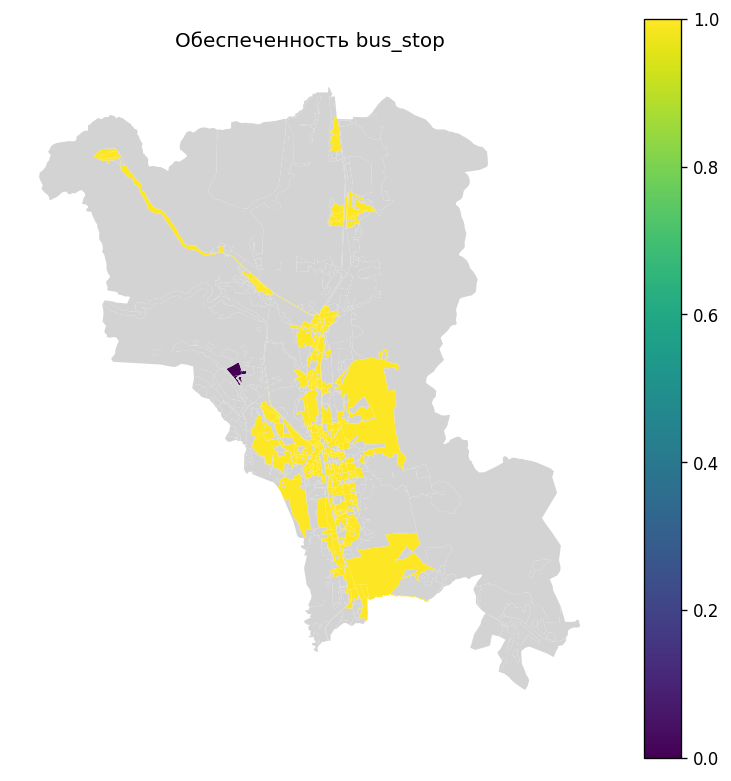


▶ competitive_provision_convenience.png


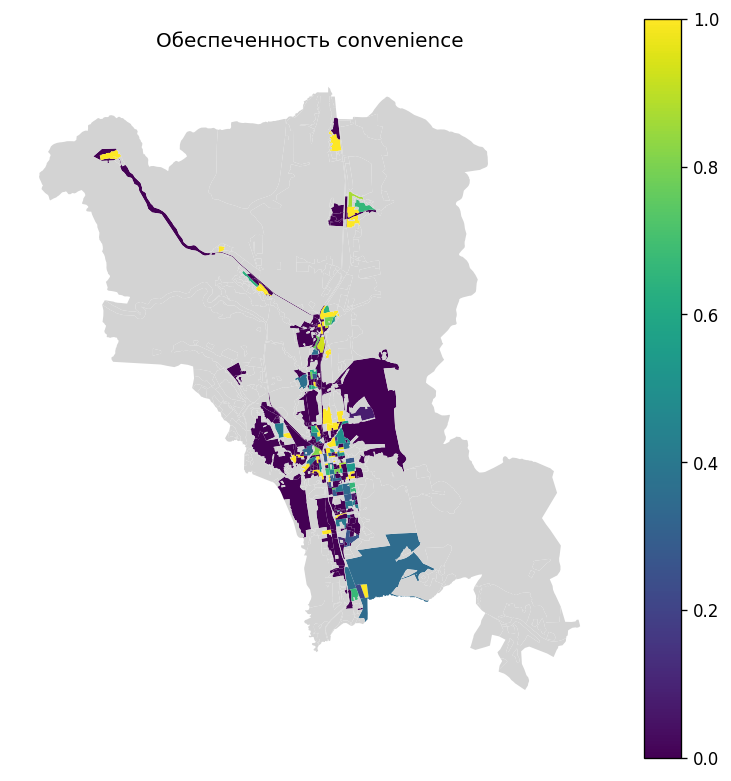


▶ competitive_provision_kindergarten.png


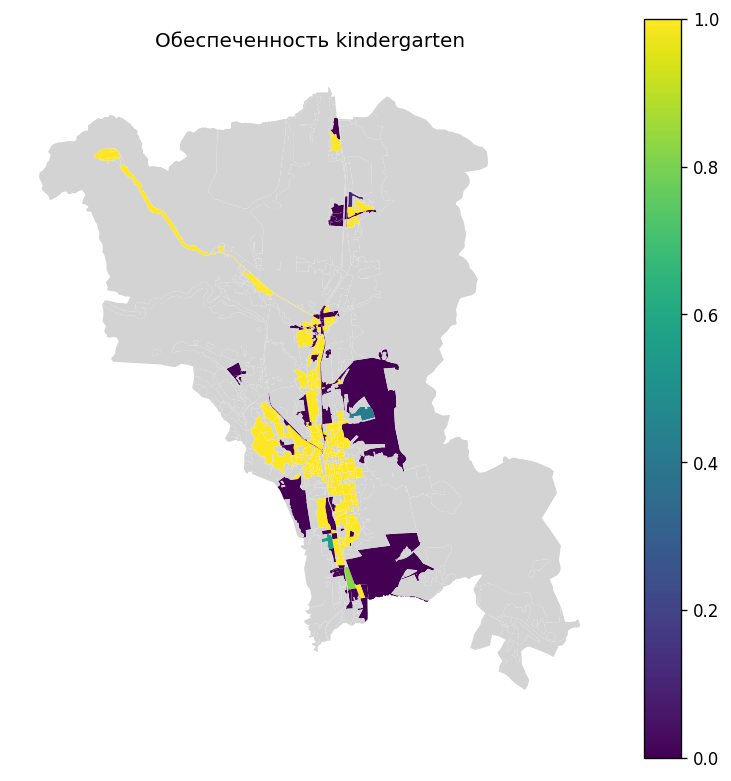


▶ competitive_provision_pharmacy.png


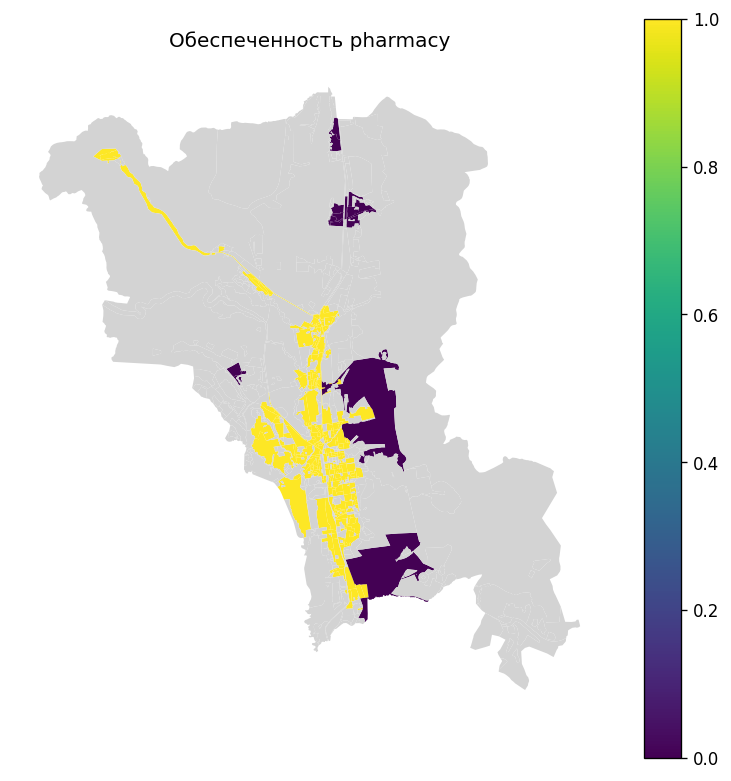


▶ competitive_provision_pitch.png


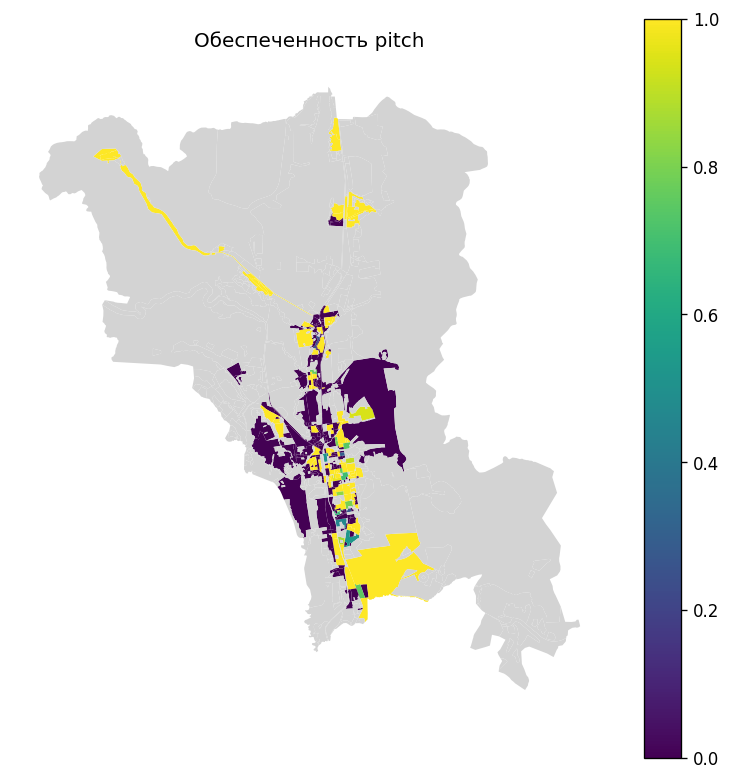


▶ competitive_provision_school.png


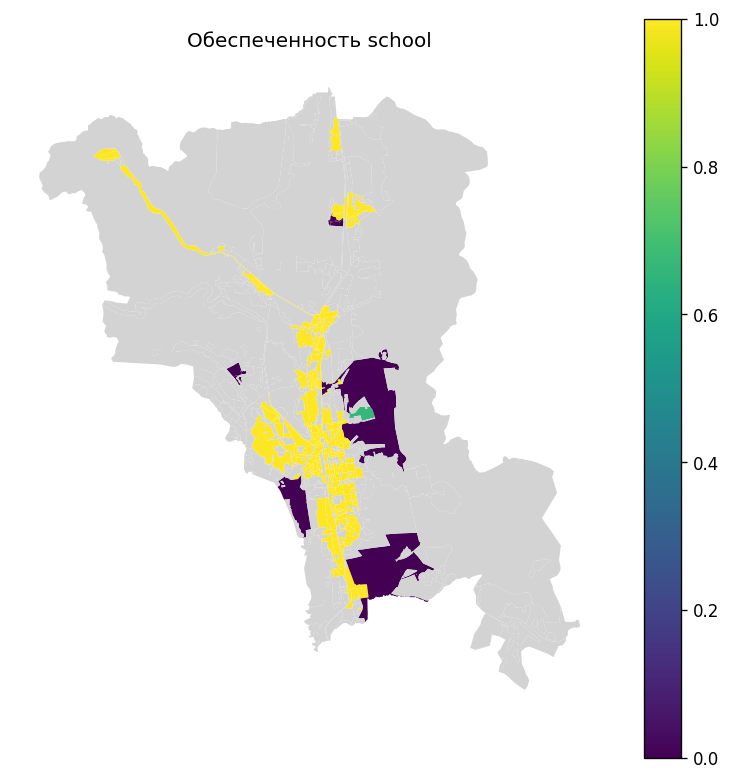


▶ connectivity.png


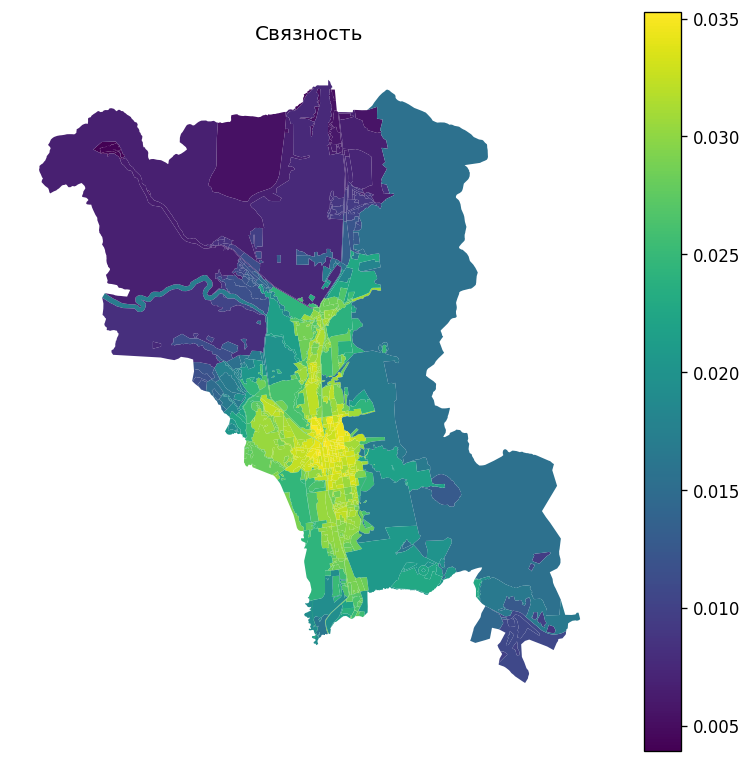


▶ proposed_services_count.png


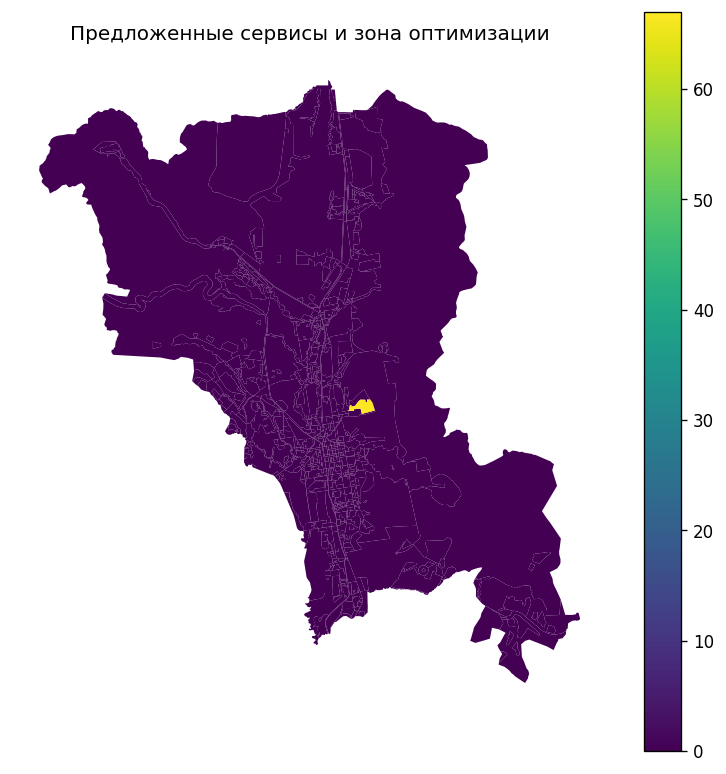


▶ services_density.png


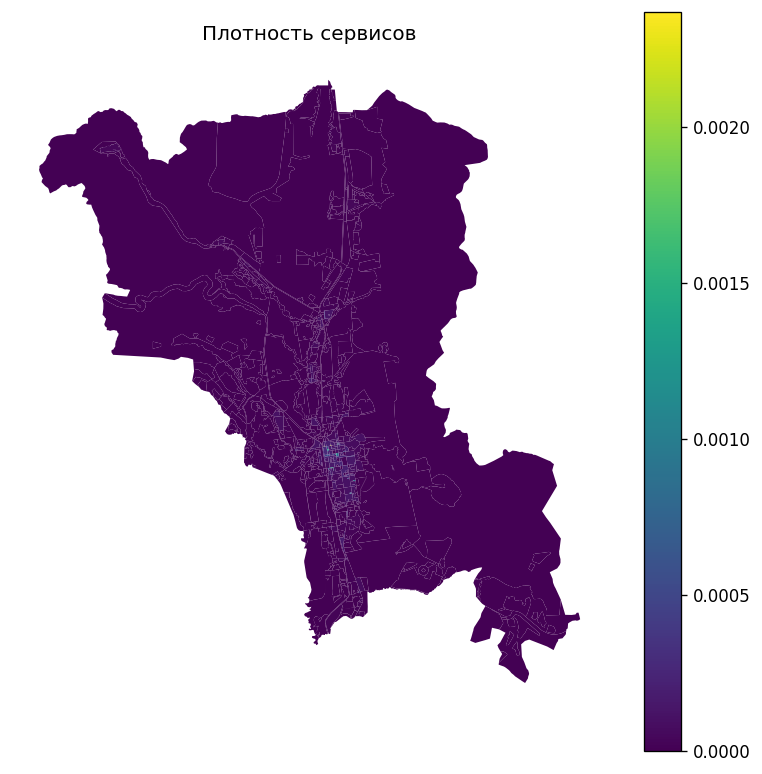


▶ shannon_diversity.png


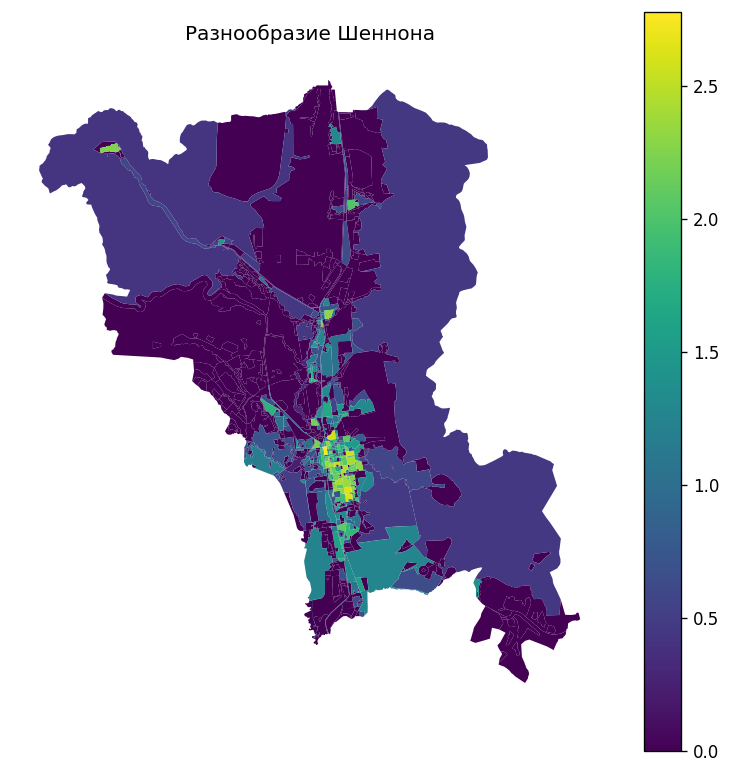

In [9]:
from IPython.display import Image, display

maps = sorted((run_dir / "maps").glob("*.png")) if run_dir.name else []
print(f"Картограмм сохранено: {len(maps)}")
for path in maps:
    print("\n\u25b6", path.name)
    display(Image(filename=str(path)))

In [10]:
# CSV-результаты расчётов в каталоге запуска
csvs = sorted(run_dir.glob("*.csv")) if run_dir.name else []
print(f"CSV-результатов: {len(csvs)}")
for path in csvs:
    print("  -", path.name)

CSV-результатов: 19
  - competitive_provision_batch_basic.csv
  - competitive_provision_bus_stop.csv
  - competitive_provision_bus_stop_links_1.csv
  - competitive_provision_convenience.csv
  - competitive_provision_convenience_links_1.csv
  - competitive_provision_kindergarten.csv
  - competitive_provision_kindergarten_links_1.csv
  - competitive_provision_pharmacy.csv
  - competitive_provision_pharmacy_links_1.csv
  - competitive_provision_pitch.csv
  - competitive_provision_pitch_links_1.csv
  - competitive_provision_school.csv
  - competitive_provision_school_links_1.csv
  - connectivity.csv
  - delta_demand.csv
  - services_density.csv
  - shannon_diversity.csv
  - solution_area.csv
  - solution_services.csv


---
### Серия экспериментов

Чтобы сравнить несколько конфигураций, измени `MODEL` / `MAX_ITERATIONS` / `QUESTION` и перезапусти ячейки 2–4, либо оберни в цикл:

```python
configs = [
    {"model": "openai/gpt-4o-mini", "max_iterations": 6},
    {"model": "openai/gpt-4o",      "max_iterations": 10},
]
rows = []
for cfg in configs:
    a = BlocksNetAgent(model=cfg["model"], max_iterations=cfg["max_iterations"])
    r = a.run(QUESTION)
    rows.append({**cfg, "confidence": r.get("confidence"), "run_dir": r.get("run_dir")})
pd.DataFrame(rows)
```